<a href="https://colab.research.google.com/github/akshitaasaxena/python-ds/blob/main/projectipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# DATA LOADING

In [39]:
df=pd.read_excel("financial_loan.xlsx")
display(df.head())

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


# METADATA

In [ ]:
df.shape

(38576, 24)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

check for null values, check if datetime columns are of their specific type, if not make the column of that datatype.

In [ ]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


insight- ek saal ka dataa hai(from issue date)

In [ ]:
#calculate total no of loan applications
total_applications=df.shape[0]
print(total_applications)

total=df['id'].nunique() # duplicate values handle krega
print(total)

38576
38576


In [ ]:
#current month me kitne applications aaye- month is dynamic
#n=input("enter month")

total1=df[df["issue_date"].dt.month==6]
display(total1.count())
num=total1['id'].nunique()
print(num)

#fordynamic
curr=(pd.Timestamp.today())
currmonth=curr.month
total1=df[df["issue_date"].dt.month==currmonth]
   #display(total1.count())
num=total1['id'].nunique()
print(num)

,0
id,3184
address_state,3184
application_type,3184
emp_length,3184
emp_title,3079
grade,3184
home_ownership,3184
issue_date,3184
last_credit_pull_date,3184
last_payment_date,3184


3184
3184


In [ ]:
current_date=pd.Timestamp.today()
current_month = current_date.month
current_day = current_date.day

loan_month_to_date = df[(df['issue_date'].dt.month == current_month) & (df['issue_date'].dt.day<=current_day)]['loan_amount'].sum()
print("TOTAL LOAN_AMOUNT IN JUNE MONTH TILL 22 : $",loan_month_to_date)

print("$",loan_month_to_date//1e6," millions")

print(f'Total loan amount in June month till 22 is $ {round(loan_month_to_date/1e6, 2)} M')

TOTAL LOAN_AMOUNT IN JUNE MONTH TILL 22 : $ 34161475
$ 34.0  millions
Total loan amount in June month till 22 is $ 34.16 M


In [ ]:
#cuurent loan-good loan
#charged off = bad loan
goodloan=df.groupby("loan_status").loc(df["loan_status"]=="Fully Paid" or df["loan_status"]=="Current")
badloan=df.groupby("loan_status").loc(df["loan_status"]=="Charged Off")
print(goodloan.count())
print(badloan.count())


AttributeError: 'DataFrameGroupBy' object has no attribute 'loc'

In [ ]:
total=df.groupby('loan_status').agg({
    'id':'count',
    'dti':'mean',
    'int_rate':'mean',
    'loan_amount':'sum',
    'total_payment':'sum'
})
total.rename(columns={'id':'no of applications'},inplace=True);
display(total)
#group by on multiple columns

,no of applications,dti,int_rate,loan_amount,total_payment
loan_status,,,,,
Charged Off,5333,0.140047,0.138786,65532225,37284763
Current,1098,0.147243,0.150993,18866500,24199914
Fully Paid,32145,0.131674,0.116411,351358350,411586256


In [ ]:
# good loan:1) application:2)funded amount 3)total received amount
good_loan_applications = total.loc[['Fully Paid','Current'], 'no of applications'].sum()
print(good_loan_applications)

good_loan_funded_amount = total.loc[['Fully Paid', 'Current'], 'loan_amount'].sum()
print(good_loan_funded_amount)
good_loan_total_received_amount = total.loc[['Fully Paid', 'Current'], 'total_payment'].sum()
print(good_loan_total_received_amount)

33243
370224850
435786170


In [ ]:
#bad loan:1) application:2)funded amount 3)total received amount
badloanapp=total.loc[["Charged Off"],'no of applications'].sum()
print(badloanapp)
badloanfunded=total.loc[['Charged Off'],'loan_amount'].sum()
print(badloanfunded)
badloantotal=total.loc[['Charged Off'],'total_payment'].sum()
print(badloantotal)

5333
65532225
37284763


# Graph Analysis


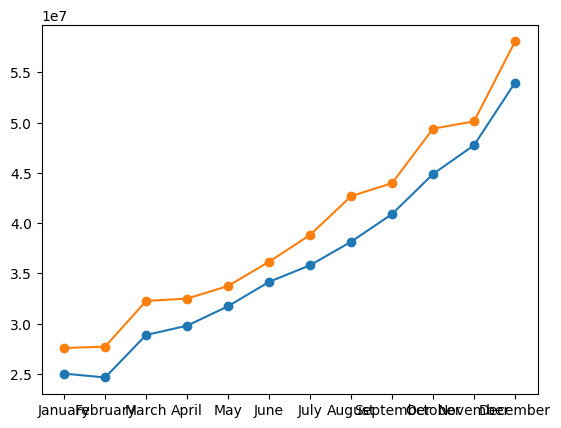

In [43]:
#trend: jan se dec loan amount kaise vary kr rha hai ?
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['month'] = df['issue_date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']
loan_amount = df.groupby('month')['loan_amount'].sum().reindex(month_order)
total_amount = df.groupby('month')['total_payment'].sum().reindex(month_order)
plt.plot(month_order, loan_amount, marker='o')
plt.plot(month_order, total_amount, marker='o')
plt.show()

# Self_Practice

In [42]:
g=df['loan_amount'].sum()
print(f'the total loan amount sanctioned was: $ {round(g/10e6,2)} millions')

the total loan amount sanctioned was: $ 43.58 millions


In [ ]:
h=df.sort_values(by='loan_amount', ascending=False)
h.iloc[0]['loan_amount']


np.int64(35000)

In [41]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

In [44]:
df['issue_date']=pd.to_datetime(df['issue_date'])
#df['month']=df['issue_date'].dt.month_name()
f=df[df['issue_date'].dt.month_name()=='December']
f=f['loan_amount'].sum()
print(f'the total loan amount sanctioned was: $ {round(f/10e6,2)} millions')


the total loan amount sanctioned was: $ 5.4 millions


In [47]:
f=df[df['issue_date'].dt.month_name()=='November']
f=f['total_payment'].sum()
print(f'the total loan amount received was: $ {round(f/10e6,2)} millions')

the total loan amount received was: $ 5.01 millions


In [52]:
f=df[df['issue_date']=='15 January 2021']

f=f['no of applications'].sum()
f

KeyError: 'no of applications'

In [80]:
b=df.groupby("month").agg({
    'loan_amount':'sum',
    'total_payment':'sum'
})
print(b.sort_values(by='loan_amount',ascending=False))
b['loan_amount'].idxmax()

           loan_amount  total_payment
month                                
December      53981425       58074380
November      47754825       50132030
October       44893800       49399567
September     40907725       43983948
August        38149600       42682218
July          35813900       38827220
June          34161475       36164533
May           31738350       33750523
April         29800800       32495533
March         28875700       32264400
January       25031650       27578836
February      24647825       27717745


'December'

In [64]:
#which purpose received highest amount
p=df.groupby('purpose').agg({
    'loan_amount':'sum',
    'total_payment':'sum'
})
p

,loan_amount,total_payment
purpose,,
Debt consolidation,232459675,253801871
car,10223575,11324914
credit card,58885175,65214084
educational,2161650,2248380
home improvement,33350775,36380930
house,4824925,5185538
major purchase,17251600,18676927
medical,5533225,5851372
moving,3748125,3999899


In [68]:
s=df.groupby('address_state').agg({
    'loan_amount':'sum',
    'total_payment':'sum'
})
s=s.sort_values(by='loan_amount',ascending=False)
s.head(10)

,loan_amount,total_payment
address_state,,
CA,78484125,83901234
NY,42077050,46108181
TX,31236650,34392715
FL,30046125,31601905
NJ,21657475,23425159
IL,17124225,18875941
VA,15982650,17711443
PA,15826525,17462908
GA,15480325,16728040
